In [2]:
import matplotlib.pyplot as plt
import numpy as np

# MD simulation to generate training data 

In [8]:
np.random.seed(3)

# Reduced units for a 2D periodic chain of identical double-well potentials
dt = 0.005
mass = 1.0
gamma = 1.0
kBT = 0.4
n_steps = 100_000
burn_in = 5_000

# Each periodic cell contains two Gaussian wells along x, with a 2D y profile.
A1, A2 = 3.0, 3.0
well_separation = 2.0
cell_spacing = 4.0
sigma_x = 0.5
sigma_y = 0.5
k_y_confinement = 0.2
n_cells = 8
box_length = n_cells * cell_spacing
cell_centers = cell_spacing * np.arange(n_cells)
well_offsets = np.array([-well_separation / 2, well_separation / 2])
well_x_centers = (cell_centers[:, None] + well_offsets).ravel()
well_y_centers = np.zeros_like(well_x_centers)
well_amplitudes = np.tile([A1, A2], n_cells)


def minimum_image(distance):
    """Return signed x distances in the periodic interval [-L/2, L/2)."""
    return (distance + 0.5 * box_length) % box_length - 0.5 * box_length


def potential(x, y):
    """Periodic 2D chain potential made from repeated Gaussian wells."""
    dx = minimum_image(np.asarray(x)[..., None] - well_x_centers)
    dy = np.asarray(y)[..., None] - well_y_centers
    gaussian = well_amplitudes * np.exp(
        -0.5 * ((dx / sigma_x) ** 2 + (dy / sigma_y) ** 2)
    )
    return -np.sum(gaussian, axis=-1) + 0.5 * k_y_confinement * np.asarray(y) ** 2


def force_x(x, y):
    """x component of the force from the periodic 2D chain potential."""
    dx = minimum_image(np.asarray(x)[..., None] - well_x_centers)
    dy = np.asarray(y)[..., None] - well_y_centers
    gaussian = well_amplitudes * np.exp(
        -0.5 * ((dx / sigma_x) ** 2 + (dy / sigma_y) ** 2)
    )
    return -np.sum(gaussian * dx / sigma_x**2, axis=-1)


def force_y(x, y):
    """y component of the force from the periodic 2D chain potential."""
    dx = minimum_image(np.asarray(x)[..., None] - well_x_centers)
    dy = np.asarray(y)[..., None] - well_y_centers
    gaussian = well_amplitudes * np.exp(
        -0.5 * ((dx / sigma_x) ** 2 + (dy / sigma_y) ** 2)
    )
    return -np.sum(gaussian * dy / sigma_y**2, axis=-1) - k_y_confinement * np.asarray(y)


# Underdamped Langevin dynamics with periodic wrapping in x only.
x, y = -well_separation / 2, 0.0
vx, vy = 0.0, 0.0
noise_scale = np.sqrt(2 * gamma * kBT * dt) / mass
x_traj, y_traj = [], []
vx_traj, vy_traj = [], []
energy_traj = []

for step in range(int(n_steps)):
    vx += (force_x(x, y) / mass - gamma * vx / mass) * dt
    vy += (force_y(x, y) / mass - gamma * vy / mass) * dt
    vx += noise_scale * np.random.normal()
    vy += noise_scale * np.random.normal()
    x = (x + vx * dt) % box_length
    y += vy * dt

    if step >= burn_in:
        x_traj.append(x)
        y_traj.append(y)
        vx_traj.append(vx)
        vy_traj.append(vy)
        energy_traj.append(potential(x, y))

positions = np.column_stack((x_traj, y_traj)).astype(np.float32)
velocities = np.column_stack((vx_traj, vy_traj)).astype(np.float32)
energy_traj = np.asarray(energy_traj, dtype=np.float32)

import datetime
date = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
np.savez_compressed(
    f"/Users/clarawimmelmann/Desktop/Energy_specialCourse/init_problem/train_data/periodic_double_well_chain_{int(n_steps)}steps_{burn_in}burn.npz",
    positions=positions,
    velocities=velocities,
    energy=energy_traj,
)

print(f"Periodic x-box length: {box_length}")
print(f"Saved positions shape: {positions.shape}")
print(f"Saved velocities shape: {velocities.shape}")
print(f"Saved energy shape: {energy_traj.shape}")

Periodic x-box length: 32.0
Saved positions shape: (95000, 2)
Saved velocities shape: (95000, 2)
Saved energy shape: (95000,)


### calculate analytical diffusion coeffecient with Kramers rule and Einstein coefficient:

In [9]:
# Measure transitions between neighboring wells in the periodic chain.
x_arr = np.asarray(x_traj)
y_arr = np.asarray(y_traj)
well_index = np.floor(x_arr / (cell_spacing / 2)).astype(int)
well_index = np.mod(well_index, 2 * n_cells)
n_transitions = np.sum(well_index[1:] != well_index[:-1])
total_time = len(x_arr) * dt
mfpt = (2 * total_time) / n_transitions if n_transitions > 0 else np.nan
k_obs = 1.0 / mfpt

# Barrier and well curvature for one repeated double-well motif at y = 0.
well_position = well_x_centers[0]
barrier_position = cell_centers[0]
V_min = potential(well_position, 0.0)
V_top = potential(barrier_position, 0.0)
delta_V = V_top - V_min

dx = 1e-4
d2V_well = (
    potential(well_position + dx, 0.0)
    - 2 * potential(well_position, 0.0)
    + potential(well_position - dx, 0.0)
) / dx**2
d2V_top = (
    potential(barrier_position + dx, 0.0)
    - 2 * potential(barrier_position, 0.0)
    + potential(barrier_position - dx, 0.0)
) / dx**2

omega_min = np.sqrt(d2V_well / mass)
omega_ts = np.sqrt(np.abs(d2V_top) / mass)
prefactor = np.sqrt(1 + (gamma / (2 * omega_ts))**2) - gamma / (2 * omega_ts)
k_kramers = prefactor * (omega_min / (2 * np.pi)) * np.exp(-delta_V / kBT)

print(f"Barrier height Delta V: {delta_V:.4f}")
print(f"Observed MD rate: {k_obs:.6f}")
print(f"Kramers analytical rate: {k_kramers:.6f}")
print(f"Ratio (observed / Kramers): {k_obs / k_kramers:.3f}")

D_0 = kBT / (mass * gamma)
print(f"Einstein diffusion coefficient: {D_0:.3f}")

Barrier height Delta V: 2.1900
Observed MD rate: 0.001053
Kramers analytical rate: 0.001960
Ratio (observed / Kramers): 0.537
Einstein diffusion coefficient: 0.400


### estimating the equilibrium step from the simulation temperature through the velocities:

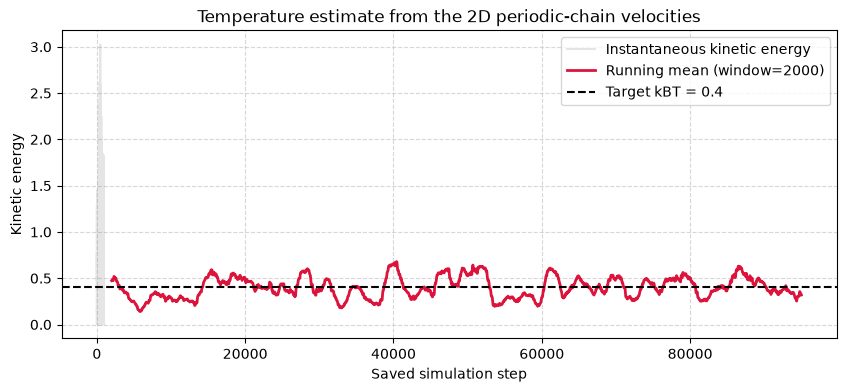

In [10]:
vx_all = np.asarray(vx_traj)
vy_all = np.asarray(vy_traj)
kBT_inst = 0.5 * mass * (vx_all**2 + vy_all**2)


def running_mean(data, window_size=1000):
    return np.convolve(data, np.ones(window_size) / window_size, mode="valid")


window = 2000
kBT_smooth = running_mean(kBT_inst, window_size=window)
steps = np.arange(len(kBT_smooth)) + window

plt.figure(figsize=(10, 4))
plt.plot(kBT_inst[::100], alpha=0.2, color="gray", label="Instantaneous kinetic energy")
plt.plot(steps, kBT_smooth, color="crimson", lw=2, label=f"Running mean (window={window})")
plt.axhline(kBT, color="black", linestyle="--", label=f"Target kBT = {kBT}")
plt.title("Temperature estimate from the 2D periodic-chain velocities")
plt.xlabel("Saved simulation step")
plt.ylabel("Kinetic energy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# visualize results:

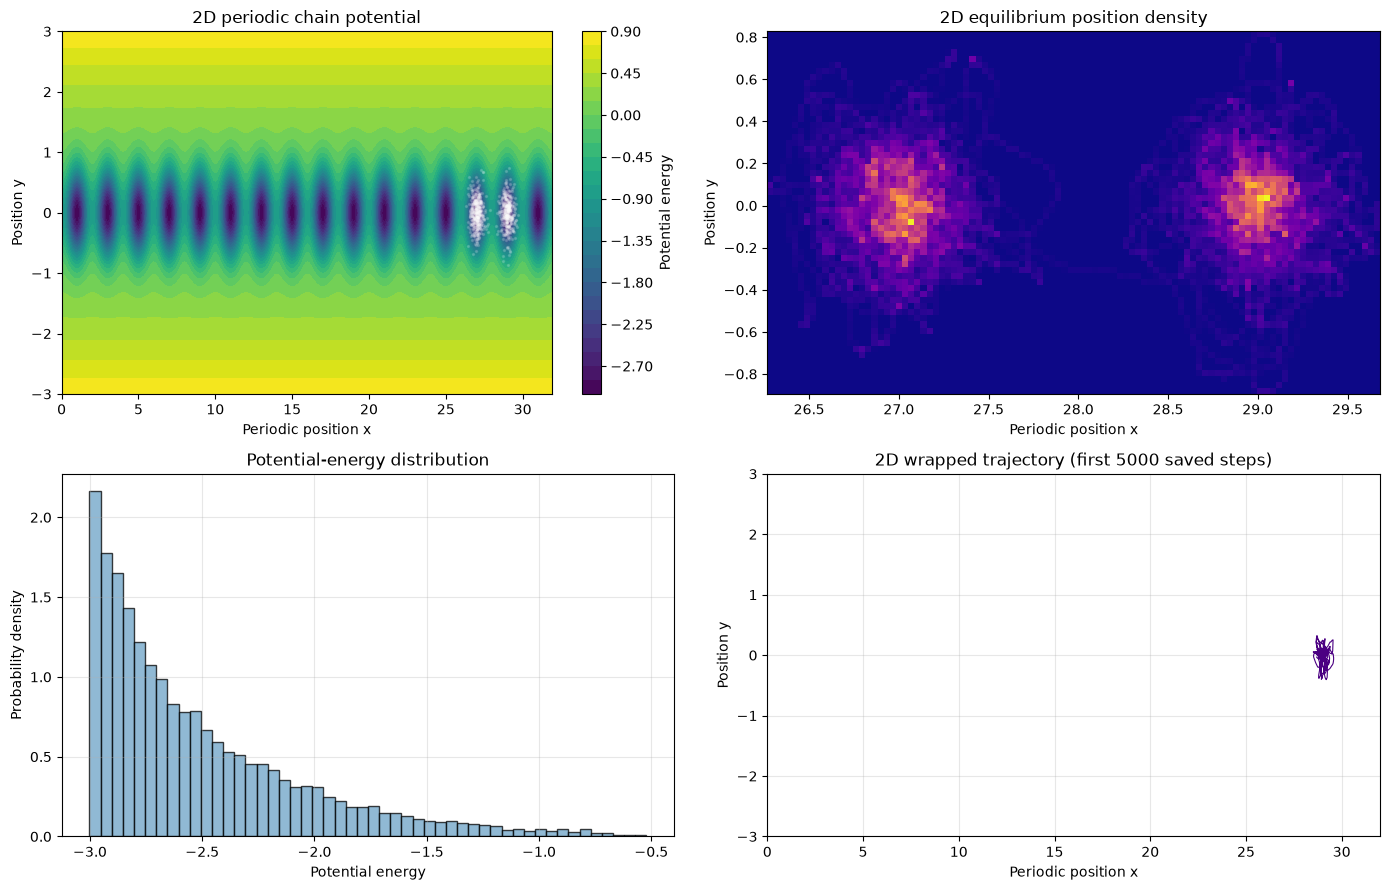

In [11]:
x_traj_arr = np.asarray(x_traj)
y_traj_arr = np.asarray(y_traj)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 2D periodic potential landscape and sampled trajectory density.
ax1 = axes[0, 0]
x_line = np.linspace(0, box_length, 300, endpoint=False)
y_line = np.linspace(-3.0, 3.0, 200)
X, Y = np.meshgrid(x_line, y_line)
Z = potential(X, Y)
contour = ax1.contourf(X, Y, Z, levels=25, cmap="viridis")
fig.colorbar(contour, ax=ax1, label="Potential energy")
ax1.scatter(x_traj_arr[::100], y_traj_arr[::100], s=2, alpha=0.15, color="white")
ax1.set_title("2D periodic chain potential")
ax1.set_xlabel("Periodic position x")
ax1.set_ylabel("Position y")

# Position density over the 2D periodic box.
ax2 = axes[0, 1]
ax2.hist2d(x_traj_arr, y_traj_arr, bins=(100, 60), cmap="plasma")
ax2.set_title("2D equilibrium position density")
ax2.set_xlabel("Periodic position x")
ax2.set_ylabel("Position y")

# Energy distribution.
ax3 = axes[1, 0]
ax3.hist(potential(x_traj_arr, y_traj_arr), bins=50, density=True, color="#6ba2c6", edgecolor="black", alpha=0.75)
ax3.set_title("Potential-energy distribution")
ax3.set_xlabel("Potential energy")
ax3.set_ylabel("Probability density")
ax3.grid(True, alpha=0.3)

# Short wrapped trajectory segment in the 2D landscape.
ax4 = axes[1, 1]
plot_steps = min(5000, len(x_traj_arr))
ax4.plot(x_traj_arr[:plot_steps], y_traj_arr[:plot_steps], color="indigo", lw=0.8)
ax4.set_xlim(0, box_length)
ax4.set_ylim(-3.0, 3.0)
ax4.set_title(f"2D wrapped trajectory (first {plot_steps} saved steps)")
ax4.set_xlabel("Periodic position x")
ax4.set_ylabel("Position y")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    f"/Users/clarawimmelmann/Desktop/Energy_specialCourse/init_problem/MD/"
    f"viz_periodic_bc_well_chain_{int(n_steps)}steps_{burn_in}burn_{date}.png",
    dpi=300,
)
plt.show()